<br/>
<img src="images/utfsm.png" alt="" width="130px" align="left"/>
<img src="images/utfsm.png" alt="" width="130px" align="right"/>
<div align="center">
<h1>Introducción a Redes Neuronales y DeepLearning</h1>
<br/><br/>
Dr. Nicolás Gálvez Ramírez<br/>
Dr. Patricio Olivares Roncagliolo<br/><br/>
Ingeniería Civil Telemática<br/>
Departamento de Eléctronica<br/>
Universidad Técnica Federico Santa María
</div>
<br>
Fuentes: 
<br>
"Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow"
<br>
"Standford - CS229 Notes"

# ¿Qué es Machine Learning?

- Machine Learning (de ahora en adelante, **ML**), se define como el conjunto de técnicas a través de los cuales un computador puede aprender de los datos.

<img src="images/diagrama.png" alt="" width="800px" align="center"/>

# ¿Por qué utilizar Machine Learning?

### Ej. Creación de un filtro de spam para correos electrónicos

- Aproximación de ML

<img src="images/withML.png" alt="" width="500px" align="center"/>

### Ej. Creación de un filtro de spam para correos electrónicos

- Aproximación tradicional

<img src="images/withoutML.png" alt="" width="500px" align="center"/>

### Ej. Creación de un filtro de spam para correos electrónicos

- Aproximación de ML

<img src="images/withML.png" alt="" width="500px" align="center"/>

# Bibliotecas para ML python

<img src="images/bibliotecas.png" alt="" width="800px" align="center"/>

# Scikit-Learn

<img src="images/scikit-learn-logo-notext.png" alt="" width="200px" align="center"/>

- Biblioteca para ML de código libre
- Biblioteca para Python
- Soporta múltiples algoritmos tanto supervisados como no supervisados
-  Si está trabajando en su entorno local, previo a su importación debe ser **instalada** 
    - ```pip install scikit-learn``` si usa ```pip```
    - ```conda install scikit-learn``` si usa ```conda```

# Scikit-Learn: Utilización

Todo los objetos Scikit-Learn son **consistentes** entre sí
* **Estimadores:** 
    - Método encargado de la **estimación** de los parámetros asociados al algoritmo. 
    - Objetos Scikit-Learn incluyen el método *fit()*, cuya entrada es el set de datos utilizados para el cálculo de los parámetros.
* **Transformadores:** 
    - Método encargado de la **transformación** de datos en base a los parámetros calculados por método *fit()*. 
    - Objetos Scikit-Learn incluyen el método *transform()*, que recibe con los datos a transformar.
    - Método *fit_transform()* permite realizar ambos pasos con un solo método.
* **Predictores:** 
    - Método encargado de hacer **predicciones** en base a datos de entrada.
    - Objetos Scikit-Learn incluyen el método *predict()*, para realizar predicciones en base a parámetros de entrada.
        
Cuáles de estos métodos están presentes, dependerá del tipo algoritmo a utilizar.
    

# División en set de training y test

- Los modelos de Machine Learning intentan aprender patrones en los datos que le permitan hacer predicciones.
- Al momento de evaluar un modelo, se desea estimar qué tan bien es capaz de **generalizar** a partir de los datos usados en el proceso de aprendizaje. (¿Puedo hacer predicciones sobre nuevos datos a partir de lo ya aprendido?)
- Para ello, siempre es necesario dividir nuestro data set en dos grupos:
    * **Training set**: Es el subconjunto de datos que será utilizado para entrenar nuestro modelo.
    * **Test set**: Es el subconjunto de datos que será utilizado para evaluar la generalización de nuestro modelo.

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [5]:
# Ejemplo de división training/test con scikit learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Carga de dataset dentro de scikit learn
# Dataset de cáncer de mamas
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(len(X_train), len(y_train))

398 398


# Tipos de errores

Para determinar el correcto funcionamiento de un algoritmo de clasificación, podemos preguntarnos

- *¿Cuántas veces acertamos la clasificación de una clase y cuántas veces no?*

Los errores que puede cometer nuestro clasificador son de dos tipos:

## Errores de Tipo 1: Falso Positivo

Clasificamos un elemento como *perteneciente* (positivo) a la clase **incorrectamente** (falso)

<img src="images/un5.jpeg" alt="" width="300px" align="center"/>

## Errores de Tipo 2: Falso Negativo

Clasificamos un elemento como *no perteneciente* (negativo) a la clase **incorrectamente** (falso)

<img src="images/noUn5.jpeg" alt="" width="300px" align="center"/>

# Matriz de confusión

Permite contar la cantidad de veces que instancias de la clase A son clasificadas como clase B

<img src="images/matrizConfusion.png" alt="" width="700px" align="center"/>
Fuente: "Hands-on Machine Learning with Scikit-Learn, Keras & Tensorflow", O'Reilly

## Ejemplo

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# Primera vez que se importa la biblioteca de aprendizaje automático scikit-learn
# No te preocupes si esto parece mucho código
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ten en cuenta que es probable que el nombre del archivo sea diferente en tu computadora (especialmente más adelante en el curso)
filename = 'data/titanic.csv'
df = pd.read_csv(filename)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Transforma la columna Sexo en una forma que no sea de texto
# Elijo cuatro funciones, podrías haber elegido otras
feature_cols = ['Pclass', 'Parch', 'Age', 'Sex']
# Convierta la columna Sexo en algo que pueda alimentar a un modelo
# Tiene
df['Sex'] = df.Sex.map({'male': 0, 
                        'female': 1})
# Eliminar filas donde la edad es nan del conjunto de datos
df = df.loc[~df['Age'].isnull(), :]
# Crear matriz de características y vector objetivo
X = df.loc[:, feature_cols]
y = df['Survived']
# Divida los datos en conjuntos de prueba y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0)
# Estandarizar datos
scaler = StandardScaler()
# Ajusta solo en el conjunto de entrenamiento
scaler.fit(X_train)
# Aplicar transformación tanto al conjunto de entrenamiento como al conjunto de prueba
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
# Crea una instancia de un modelo
logreg = LogisticRegression()
# Entrena el modelo con los datos
logreg.fit(X_train, y_train);
# predicciones de clase (no probabilidades predichas)
predictions = logreg.predict(X_test)
print(predictions)
print(y_test.tolist())

[1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 1 1
 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0
 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 1 0 0 1 0 1 1 0 0 0 1
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0]
[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0]


In [9]:
# valores reales: y_test.values
# predicciones: predicciones del modelo
print("Total de elementos:", len(y_test.values))
cm = metrics.confusion_matrix(y_test.values, predictions)
print(cm)
print(cm.ravel())
tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)

Total de elementos: 179
[[87 16]
 [17 59]]
[87 16 17 59]
87 16 17 59


# Medidas para clasificación

## Accuracy (exactitud)

- Fracción de casos correctamente clasificados sobre casos totales (¿Cuántas veces acerté?)

$$ \text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

- En nuestra matriz de confusión anterior, sería

$$\text{accuracy} = \frac{87 + 59}{87 + 16 + 17 + 59} = 0.8156 = 81.56\%$$

In [10]:
score = logreg.score(X_test, y_test) # Esta línea, para este modelo, calcula el accuracy
print("Score obtenido por Regresor", score)
manual_score = (tp + tn)/(tp + tn + fp + fn)
print("Score obtenido manualmente", manual_score)

Score obtenido por Regresor 0.8156424581005587
Score obtenido manualmente 0.8156424581005587


El accuracy es una excelente medida, pero presenta algunos problemas. Veamos un ejemplo para un "clasificador de 5s"

In [11]:
# Ej. Modelo de clasificación de 5s
import numpy as np
# Datos de entrenamiento
datos = [1,2,1,3,4,2,5,3,4,6,5,4,2,7,9,8,9,6,4,5]
# Valor a predecir. 1 representa la existencia de un 5 y 0 la ausencia del mismo.
valores_reales = [0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1]

# Crearemos el modelo "Nada es 5". Este modelo decide que ningún número es 5
# Emularemos las predicciones de este modelo que clasifica todo como
# "No 5" en la siguiente variable
predicciones = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0] # Crea una lista de 0s
print(predicciones)
print(valores_reales)
# Nuestro modelo clasifica todo como NO 5
tn=17 # 17 son los números que no eran 5, por lo tanto nuestro modelo los clasifico bien
tp=0 # Como no clasificamos ningún 5, los TP son
fn=3 # Los 5s que clasificamos incorrectamente, están acá
fp=0 # No hicimos ninguna clasificación FP.

# Ejecuta esta celda y ve qué accuracy obtiene este modelo!
accuracy = (tn+tp)/(tn+tp+fn+fp)
print(accuracy*100)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
85.0


A pesar de haber creado un mal modelo, obtuvimos un alto accuracy. Esto se debe a que el accuracy hace un importante supuesto:Los datos de las clases positiva y negativa deben ser **COMPARABLES** en cantidad, lo cual no siempre ocurre.

## Sensitivity/Recall/True Positive Rate (sensibilidad)

- Fracción de casos **pertenecientes** a una clase correctamente clasificados (¿Cuántas veces acerté al clasificar la clase X?)

$$ \text{sensitivity} = \frac{TP}{TP + FN} = \frac{\text{Positivos correctamente clasificados}}{\text{Positivos reales totales}} $$

In [ ]:
# Ahora, calculemos la sensibilidad de nuestro modelo de
# No 5s
sensitivity = tp/(tp+fn)
print(sensitivity*100)

## Specificity/Selectivity/True Negative Rate (especificidad)

- Fracción de casos **no pertenecientes** a una clase correctamente clasificados (¿Cuántas veces acerté al clasificar casos fuera de la clase X?)

$$ \text{specificity} = \frac{TN}{TN + FP} $$

In [ ]:
# Calculemos ahora la especificidad de nuestro modelo
# No 5s
specificity = (tn)/(tn + fp)
print(specificity*100)

## Precision/Positive predictions (precisión)

- Fracción de casos clasificados como **positivos** que fueron correctamente clasificados (¿Cuántos casos clasificados como X fueron acertados?)

$$ \text{precision} = \frac{TP}{TP + FP} = \frac{\text{Casos correctamente clasificados}}{\text{Casos totales clasificados como Positivos}} $$

In [ ]:
# Calculemos la precision de nuestro modelo
# No 5s
#precision = tp/(tp+fp) # Como no hay ningún caso clasificado como positivo, denominador cero
#print(precision*100)

# Redes neuronales (Neural Networks - NN)

- Las Redes Neuronales son un conjunto de modelos de Machine Learning.
- Estas se inspiran en el funcionamiento neurológico del cerebro humano.
- Las redes neuronales han sido utilizadas en múltiples y diferentes áreas de aplicación

### Ejemplos de aplicaciones Deep Learning

- [DeepMind](https://www.youtube.com/watch?v=V1eYniJ0Rnk)
- [Gaugan2](http://gaugan.org/gaugan2/?text_input=ocean+waves+in+a+beach)
- [YoloV3](https://www.youtube.com/watch?v=MPU2HistivI)
- [QuickDraw](https://quickdraw.withgoogle.com/#)
- [Rock-Paper-Scisors](https://tenso.rs/demos/rock-paper-scissors/)
- [ChatGPT](https://chat.openai.com/)
- Y una laaaarga [lista](https://www.mygreatlearning.com/blog/deep-learning-applications/#deepdreaming)

# Perceptrón

- Es la red neuronal más sencilla cuya base es la TLU (Threshold Logic Unit)
- TLU es una neurona artificial que opera de la siguiente manera
    - Recibe una o varias entradas numéricas (datos de entrenamiento) $\mathbf{x}=(x_1, x_2, ..., x_n)$
    - Cada entrada es ponderada por un peso $\mathbf{w}=(w_1x_1, w_2x_2, ..., w_nx_n)$ 
    - Se calcula la suma ponderada de las entradas $z=w_1x_1 + w_2x_2 + ... +w_nx_n = \mathbf{x}^T \mathbf{w}$
    - Al resultado de la suma ponderada se le aplica una función llamada función de activación $h_{\mathbf{w}}(\mathbf{x})$. El resultado corresponde a la predicción $\hat{y}$.
    
$$z=x_0 + w_1x_1 + w_2x_2 + ... +w_nx_n = \mathbf{x}^T \mathbf{w}$$
$$ \hat{y} = h_{\mathbf{w}}(\mathbf{x}) = h(z) = h(\mathbf{x}^T \mathbf{w})$$

<img src="images/perceptron.png" width="700px">

In [ ]:
# Ejemplo de un perceptrón utilizando la biblioteca Scikit-Learn
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

per = Perceptron()
per.fit(X_train, y_train)
print("Training score:", per.score(X_train, y_train)) # Accuracy de entrenamiento
print("Test score:", per.score(X_test, y_test)) # Accuracy de testing

In [ ]:
print("Los valores reales:", y_test)
print("Predicciones:", per.predict(X_test))

# Gradient descent

- Al entrenar una neurona, lo que se intenta determinar son los **pesos** $\mathbf{w}$ tales que la predicción $h_{\mathbf{w}}(\mathbf{x})$ sea lo más cercana al valor esperado.
- Considere el Suma de Errores Cuadrático (SSE) entre la salida de la neurona ($\hat{y}$) y el valor real esperado ($y$).
    $$ J(\mathbf{w}) = \text{SSE} = \frac{1}{2} \sum_{i=1}^{m} \left( \hat{y}^{(i)}  - y^{(i)} \right)^2 = \frac{1}{2} \sum_{i=1}^{m} \left( h(\mathbf{w}^T \mathbf{x}^{(i)} )  - \mathbf{y}^{(i)} \right)^2$$
donde $\mathbf{X}$ es la matriz de datos de entrada (datos de entrenamiento), $\mathbf{w}$ es el vector de pesos, $\mathbf{y}$ es el vector de salidas esperadas, $m$ es el total de muestras (datos de entrenamiento).

Al necesitarse que los valores de $\hat{\mathbf{y}}$ e $\mathbf{y}$ sean los más cercanos posibles, el SSE puede ser utilizado como médida. Por lo tanto, **debemos ajustar los valores de $\mathbf{w}$ de tal manera que el SSE sea el *menor* posible**.

$$ \min_{\mathbf{w}} J(\mathbf{w}) = \min_{\mathbf{w}} \frac{1}{2} \sum_{i=1}^{m} \left( h(\mathbf{w}^T \mathbf{x}^{(i)} )  - \mathbf{y}^{(i)} \right)^2$$

- El algoritmo de descenso del gradiente o Gradient Descent, permite calcular el mínimo local de una función
- Se define a través de la siguiente regla de actualización para cada elemento $w_j$ perteneciente al vector de pesos $\mathbf{w}$.

$$ w_j := w_j - \alpha \nabla_{w_j}J(\mathbf{w})   $$
- Gradient Descent se utiliza para actualizar los pesos de la neurona al momento de entrenar.
- Actualiza el valor de cada peso $w_j$ utilizando el gradiente de la función de costo definida anteriormente como base para la actualización (avanzo por el lugar que minimice el error de $J(\mathbf{w})$)

# Back Propagation

- Back Propagation es un algoritmo que permite el cálculo de los gradientes requeridas por Gradient Descent utilizando la regla de la cadena.
- Estas derivadas se "propagan hacia atrás" de manera que el cálculo de una derivada se puede reutilizar para múltiples derivadas que dependan de ella por la regla de la cadena.
- Considere la siguiente red neuronal simple:

<img src="images/nn_simple.png" width="700px">

- Calculando la función de costo para una instancia, se obtiene lo siguiente:

$$ J = (\textbf{a}^{(3)} - \textbf{y})$$

Donde $\textbf{a}^{(3)}$ se puede definir de la siguiente manera:

$$
\textbf{a}^{(3)} = \textbf{h}^{(3)}\left(\textbf{z}^{(3)}\right) = \textbf{h}^{(3)}\left( \textbf{a}^{(2)} \cdot \textbf{w}^{(3)} \right)
$$ 

donde $\textbf{h}^{(i)}$ representa la función de activación de la capa $i$
- A continuación calcularemos cómo varía la función de costo (error) cuando modifico $\textbf{w}^{(3)}$. Por regla de la cadena, se tiene

$$\frac{\partial J}{\partial \textbf{w}^{(3)}} = \frac{\partial \textbf{z}^{(3)}}{\partial \textbf{w}^{(3)}} \cdot \frac{\partial \textbf{a}^{(3)}}{\partial \textbf{z}^{(3)}} \cdot \frac{\partial J}{\partial \textbf{a}^{(3)}}$$

- Calculando cada derivada
\begin{equation}
\begin{split}
    \frac{\partial J}{\partial \textbf{a}^{(3)}} &= \frac{\partial}{\partial \textbf{a}^{(3)}} (\textbf{a}^{(3)} - \textbf{y})^2 = 2(\textbf{a}^{(3)} - \textbf{y}) \\
    \frac{\partial \textbf{a}^{(3)}}{\partial \textbf{z}^{(3)}} &= \frac{\partial}{\partial \textbf{z}^{(3)}} \textbf{h}^{(3)}(\textbf{z}^{(3)}) = \textbf{h}'^{(3)}(\textbf{z}^{(3)})\\
        \frac{\partial \textbf{z}^{(3)}}{\partial \textbf{w}^{(3)}} &= \frac{\partial}{\partial \textbf{w}^{(3)}}(\textbf{a}^{(2)} \textbf{w}^{(3)}) = \textbf{a}^{(2)}
\end{split}
\end{equation}
- Todas las derivadas anteriores son fácilmente calculables, excepto $\textbf{h}'^{(3)}$, pues depende de la función de activación escogida.

- Veamos qué ocurre cuando calculamos cómo varía la función de costo cuando modificamos $\textbf{w}^{(2)}$


\begin{equation}
\begin{split}
    \frac{\partial J }{\partial \textbf{w}^{(2)}} &= \frac{\partial \textbf{z}^{(2)}}{\partial \textbf{w}^{(2)}} \cdot \frac{\partial \textbf{a}^{(2)}}{\partial \textbf{z}^{(2)}} \cdot \frac{\partial \textbf{z}^{(3)}}{\partial \textbf{a}^{(2)}} \cdot \boxed{\frac{\partial a\textbf{a}^{(3)}}{\partial \textbf{z}^{(3)}} \cdot \frac{\partial J}{\partial \textbf{a}^{(3)}}}
\end{split}
\end{equation}

donde las últimas dos derivadas fueron también calculadas para $\frac{\partial J}{\partial \textbf{w}^{(3)}}$. Eso quiere decir que la derivadas ya calculadas pueden ser reutilizadas o **propagadas hacia atrás** en el cálculo de Gradient Descent para otros pesos.

# Redes multicapas y Deep Learning

- Es posible conectar múltiples neuronas entre sí tomando la salida de una neurona como la entrada para una o múltiples neuronas adicionales.
- Las conexiones que se producen entre neuronas conforman lo que se llama como **red neuronal**.
- Dependiendo de cuales sean las conexiones entre distintas neuronas, se habla de la **arquitectura** de la red neuronal.
- Las redes neuronales se dividen en **capas**, las cuales se dividen en las siguientes categorías:
    - Capas de entrada (input layers)
    - Capas de salida (output layers)
    - Capas ocultas/intermedias (hidden layers)
- Las redes multicapas están compuestas por una capa de entrada, una o varias capas ocultas y una capa de salida
- Cuando una red multicapa contiene muchas capas ocultas, hablamos de una **Red Neuronal Profunda** (Deep Neural Network - DNN)

<img src="images/dnn.png" width="700px">

- Al igual que en el perceptron, deseamos calcular los pesos $w$ de todas las neuronas tales que la salida esté lo más cercana a los valores esperados. 
- ¿Cómo podemos calcular tantos pesos a la vez? 
    - **R:** Backpropagation 

# Backpropagation

- Back propagation es el procedimiento que se utiliza para calcular los valores de las derivadas parciales $\nabla_{w_j}J(\mathbf{w})$ de la función de costo sobre cada peso de la red.
- Se basa en la regla de la cadena para propagar los gradientes de capas posteriores para calcular los gradientes de capas anteriores. 

# Funciones de activación

- Las funciones de activación permiten agregar no linealidades a una neurona.
- Existen muchas funciones de activación. Algunas enfocadas en **regresión** (predicción de valores numéricos) y otras en **clasificación** (predicción de clases).
- Ejemplos:

### Linear
$$
\text{Linear}(x)=x
$$  

- Se usa principalmente en problemas de regresión.  
- No introduce no linealidad, por lo que hoy se utiliza poco en redes profundas.  

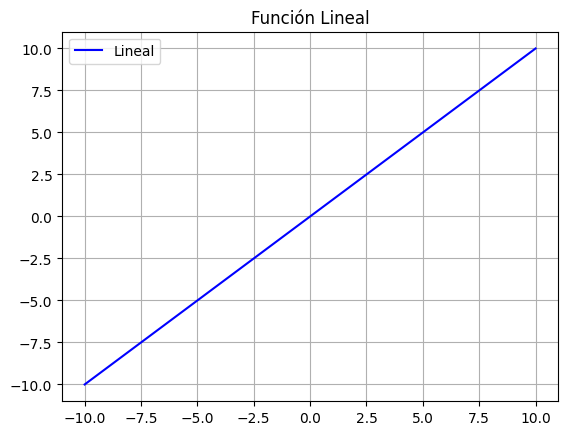

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def linear(x):
    return x

x = np.linspace(-10, 10, 500)
plt.plot(x, linear(x), color="blue", label="Lineal")
plt.title("Función Lineal")
plt.grid(True)
plt.legend()
plt.show()

### Sigmoide
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$  
- Convierte la salida en valores entre 0 y 1, interpretables como probabilidades.  
- Común en problemas de clasificación binaria.  

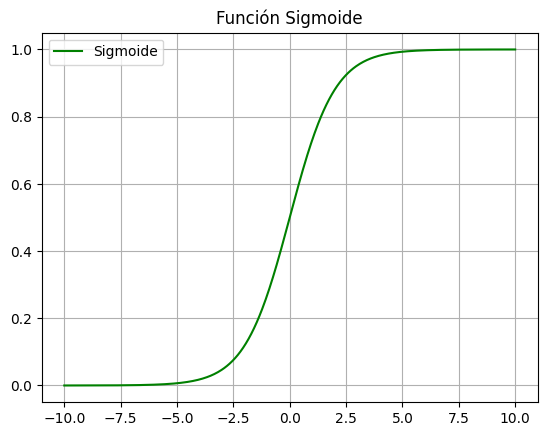

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 500)
plt.plot(x, sigmoid(x), color="green", label="Sigmoide")
plt.title("Función Sigmoide")
plt.grid(True)
plt.legend()
plt.show()

### ReLU (Rectified Linear Unit)
$$
\text{ReLU}(x) = \max(0, x) 
$$  
- Muy usada en capas intermedias por su simplicidad y eficiencia.  
- Permite entrenar redes profundas evitando el problema de gradientes pequeños.  

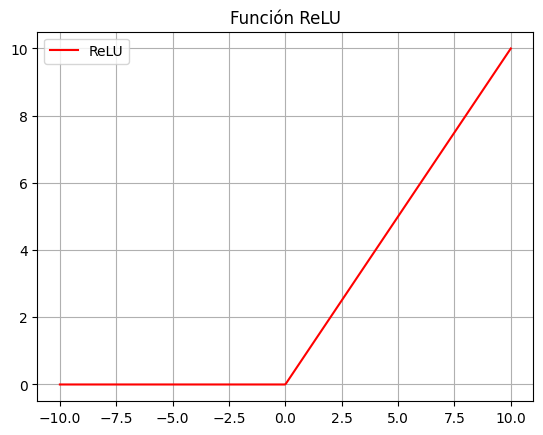

In [9]:
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 500)
plt.plot(x, relu(x), color="red", label="ReLU")
plt.title("Función ReLU")
plt.grid(True)
plt.legend()
plt.show()


### Leaky ReLU
$$
\text{LeakyReLU}(x) =
\begin{cases}
x, & \text{si } x > 0 \\
\alpha x, & \text{si } x \leq 0
\end{cases}
$$  
- Variante de ReLU que evita neuronas inactivas (salidas siempre cero).  
- Útil cuando se requiere mantener un gradiente pequeño en la parte negativa.  

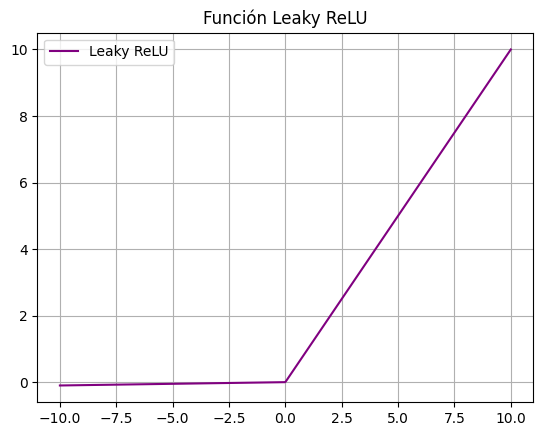

In [7]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-10, 10, 500)
plt.plot(x, leaky_relu(x), color="purple", label="Leaky ReLU")
plt.title("Función Leaky ReLU")
plt.grid(True)
plt.legend()
plt.show()



### Función Tangente Hiperbólica (Tanh)
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$  
- Sus valores van entre -1 y 1, centrados en cero.  
- Útil en capas intermedias donde se requiere normalizar la salida.  

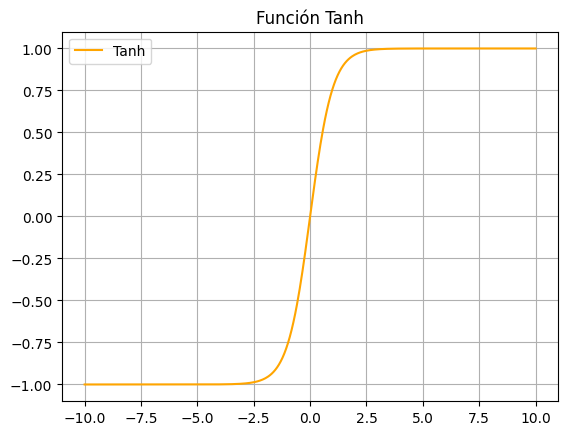

In [8]:
def tanh(x):
    return np.tanh(x)

x = np.linspace(-10, 10, 500)
plt.plot(x, tanh(x), color="orange", label="Tanh")
plt.title("Función Tanh")
plt.grid(True)
plt.legend()
plt.show()

### Función Softmax
$$
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}}
$$  
- Generalización de la sigmoide para múltiples clases.  
- Se usa en la capa de salida de redes para clasificación multiclase.  

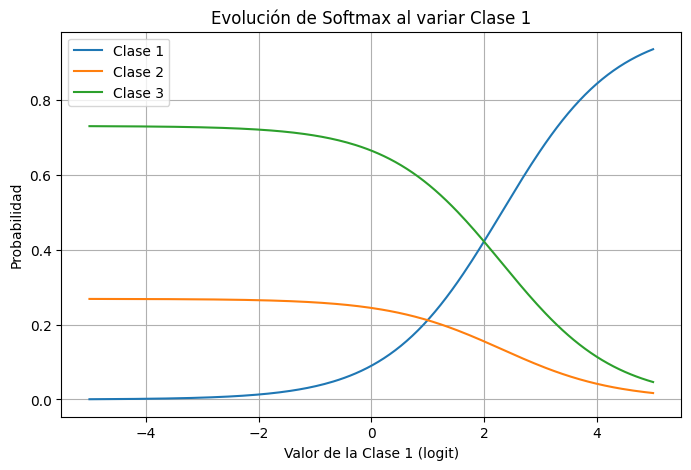

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    exp_x = np.exp(x - np.max(x))  # estabilidad numérica
    return exp_x / exp_x.sum()

# Rango de valores para la primera clase
x_vals = np.linspace(-5, 5, 200)

# Guardamos probabilidades
probs = []
for val in x_vals:
    logits = np.array([val, 1.0, 2.0])  # Clase 1 varía, Clases 2 y 3 fijas
    probs.append(softmax(logits))

probs = np.array(probs)

# Graficamos cómo varían las probabilidades
plt.figure(figsize=(8,5))
plt.plot(x_vals, probs[:,0], label="Clase 1")
plt.plot(x_vals, probs[:,1], label="Clase 2")
plt.plot(x_vals, probs[:,2], label="Clase 3")
plt.title("Evolución de Softmax al variar Clase 1")
plt.xlabel("Valor de la Clase 1 (logit)")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(True)
plt.show()



# Google Colaboratory
<img src="images/colab_favicon_256px.png" width="100px">

- Proyecto basado en Jupyter Notebook (sistema ampliamente usado en Data Science)
- Permite escribir y ejecutar código Python en el navegador 
    - Sin configuración requerida
    - Acceso gratuito a GPU (Graphic Process Unit)
    - Facilidad para compartir (en la nube)

<center>
    <img src="images/colab_note.png" width="900px" >
</center>

# Bibliotecas de Deep Learning

- Actualmente existe una amplia gama de bibliotecas para Deep Learning. 
- Por su facilidad de uso y popularidad, utilizaremos la API de **Keras**, la cual viene incluida dentro de la biblioteca **Tensorflow**.
- Para poder utilizar Keras, es necesario tener previamente instalado Tensorflow (```pip install tensorflow```)

<img src="images/bibliotecas.png" width="700px">

# Creando redes neuronales en Keras

Para crear una red neuronal, debemos
- Definir la arquitectura de la red (modelo y capas)
- Compilar el modelo (selección de optimizador, función de pérdida y métricas)
- Entrenar modelo
- Usar!

In [ ]:
# ESTA CELDA NO ES OBLIGATORIA. EL PROFE DE CCCV LA USA PORQUE TIENE DOS GPU!!
import os

os.environ["CUDA_VISIBLE_DEVICES"]="0" # Para utilización de GPU en particular

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
# Ejemplo usando fashion mnist
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Cost",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"] # 10 clases

X_train_full = X_train_full/255.0 # Escalamiento

In [ ]:
# Esta celda muestra algunas imágenes del dataset como ejemplo
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,15))

for i in range(36):
    ax = fig.add_subplot(6,6,i+1)
    ax.imshow(X_train_full[i], cmap='gist_yarg')
    ax.set_title(class_names[y_train_full[i]])

plt.show()
    

In [ ]:
# Acá armaremos nuestra red neuronal (la arquitectura)
# Recuerda que en este punto se debe escoger tanto el modelo, la cantidad de capas, el tipo de capas,
# cantidad de neuronas, etc.
# Armado de nuestra red neuronal
model = tf.keras.models.Sequential() # Modelo secuencial
model.add(tf.keras.layers.Flatten(input_shape=[28, 28])) # Capa de entrada, tiene dimensiones 28x28
model.add(tf.keras.layers.Dense(300, activation='relu')) # Primera capa oculta, salida 300
model.add(tf.keras.layers.Dense(100, activation='relu')) # Segunda capa oculta, salida 100
model.add(tf.keras.layers.Dense(10, activation='softmax')) # Capa de salida, salida 10 (número de clases)
# Importante 
# -Para un modelo de clasificación multiclase debes tener tantas neuronas en la capa de salida como clases tenga
# tu dataset
# - La función de activación DEBE ser softmax de la capa de salida

In [ ]:
# Red creada
model.summary()

In [ ]:
# En el proceso de compilación, la función de perdida DEBE ser sparse_categorical_crossentropy
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

# Ejemplos de métricas
# metrics=[tf.keras.metrics.Accuracy(), tf.keras.metrics.FalsePositives()]

In [ ]:
from sklearn.model_selection import train_test_split
# Utilización de datos de validación y entrenamiento del modelo
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, 
                                                  stratify=y_train_full)

In [ ]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_val, y_val))

In [ ]:
X_test = X_test/255.0 # nuevamente, escalamiento de set de datos de entrenamiento
loss, acc = model.evaluate(X_test, y_test, verbose=2)
print("Loss:", loss) # Función de pérdida
print("Accuracy:", acc)

In [ ]:
import numpy as np
#dato = 56
#dato = 74
dato=12
prediction = model.predict(X_test)
print(prediction[dato])
classes_x=np.argmax(prediction,axis=1)
print("Predicción:", class_names[classes_x[dato]])
print("Clase Real:", class_names[y_test[dato]])

# Regularización en NN

- La gran cantidad de parámetros que posee una red neuronal, si bien, entrega una gran flexbilidad de ajuste a una enorme cantidad de datos distintos, esto también las hace propensas al overfitting (sobre ajuste).
- Para evitar el overfitting, al igual en otros métodos, necesitamos utilizar técnicas de **regularización**.
- Algunas de las técnicas más populares son:
    - Regularización $l_1$ y $l_2$
    - Dropout (dilución)
    - Early stop (detención anticipada)

In [ ]:
# Ejemplo
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv('data/nba.csv', index_col = 'Name')
df.head()

In [ ]:
# Botar faltantes
df.dropna(inplace = True)
# Guardar X datos
X = df.drop(columns = 'TARGET_5Yrs')
# Codificar nuestro objetivo
y = df['TARGET_5Yrs']

In [ ]:
# División entrenamiento, validación, prueba
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [ ]:
# Escalamiento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Input shape
input_shape = X_train.shape[1]
print(input_shape)

In [ ]:
# Modelo sin regularización
model = Sequential()
# Primera capa oculta
model.add(Dense(19,
                input_dim = input_shape, 
                activation = 'relu')) 
model.add(Dense(10, 
                activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile(loss = 'bce', optimizer = 'adam' , metrics=['accuracy']) # bce: binary cross entropy
history = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val), 
                    epochs=100)

In [ ]:
# Visualizar la perdida
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend();

In [ ]:
# Visualizar el accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend();

# Regularización $l_1$ y $l_2$

- Las regularización $l_1$ y $l_2$ agregan factores a la función de costo de una red neuronal para impedir que los pesos de esta tomen cualquier valor (multiplicadores de Lagrange).
- Las regularizaciones de tipo $l_1$ y $l_2$ se definen de la siguiente manera sobre la función de costo:
    - Regularización $l_1$
\begin{equation}
\begin{split}
    J = \frac{1}{m}\sum_{i=1}^{m} \left( \hat{\textbf{y}}^{(i)} - \textbf{y}^{(i)} \right)^{2}  + \boxed{\alpha \frac{1}{n} \sum_{j=1}^{n} |\textbf{w}_{i} |}
\end{split}
\end{equation}
    - Regularización $l_2$
\begin{equation}
\begin{split}
    J = \frac{1}{m}\sum_{i=1}^{m} \left( \hat{\textbf{y}}^{(i)} - \textbf{y}^{(i)} \right)^{2}  + \boxed{\alpha \frac{1}{2n} \sum_{j=1}^{n} \textbf{w}_{i}^2}
\end{split}
\end{equation}

In [ ]:
from tensorflow.keras.regularizers import l2
# Con Regularización l2
# Modelo secuencial
model = Sequential()
# Primera capa oculta
model.add(Dense(19, # Cuántas neuronas tienes en tu primera capa oculta
                input_dim = input_shape, # ¿Cuál es la forma de tus características de entrada (número de columnas)?
                activation = 'relu',
                kernel_regularizer=l2(0.01))) # ¿Qué función de activación estás usando?
model.add(Dense(10, 
                activation = 'relu',
                kernel_regularizer=l2(0.01)))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam', metrics=['accuracy'])
history_l2 = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val), 
                    epochs=100)

In [ ]:
plt.plot(history_l2.history['loss'], label='Train loss')
plt.plot(history_l2.history['val_loss'], label='Val Loss')
plt.legend();

# Dropout

- Un algoritmo sencillo que ha mostrado ser muy efectivo al entrenar redes neuronales
- En cada iteración de entrenamiento, cada neurona (excepto las neuronas de salida) tiene una probabilidad $p$ de ser **excluída** (ignorada).
- La probabilidad $p$ es llamada **tasa de dropout**. Por lo general esta tasa se escoge como:
    - Entre 40%-50% para redes convolucionales
    - Entre 20%-30% para redes recurrentes
    - Para otras redes, se puede escoger valores entre el 10% hasta el 50%

<img src="images/dropout.png" width="500px">

In [ ]:
from tensorflow.keras.layers import Dropout
# Con Dropout
# Modelo secuencial
model = Sequential()
# Primera capa oculta
model.add(Dense(19, # Cuántas neuronas tienes en tu primera capa oculta
                input_dim = input_shape, # ¿Cuál es la forma de tus características de entrada (número de columnas)?
                activation = 'relu')) # ¿Qué función de activación estás usando?
# A continuación agregamos nuestra capa de dropout
model.add(Dropout(.3))
model.add(Dense(10, 
                activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam', metrics=['accuracy'])
history_dropout = model.fit(X_train, y_train,
                    validation_data = (X_val, y_val), 
                    epochs=100)

In [ ]:
plt.plot(history_dropout.history['loss'], label='Train loss')
plt.plot(history_dropout.history['val_loss'], label='Val Loss')
plt.legend();

# Early stop (detención temprana)

- Para algoritmos iterativos que tienden al overfitting, el early stopping propone dejar de entrenar tan pronto se alcanza el mínimo error. 
- En el ejemplo se ve que el error de validación aumenta en la medida que aumentan los epochs. Early stop mantendrá aquel modelo que entrega el menor error de validación.

In [ ]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend();

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# Con detención anticipada
# Modelo secuencial
model = Sequential()
# Primera capa oculta
model.add(Dense(19, # Cuántas neuronas tienes en tu primera capa oculta
                input_dim = input_shape, # ¿Cuál es la forma de tus características de entrada (número de columnas)?
                activation = 'relu')) # ¿Qué función de activación estás usando?
model.add(Dense(10, 
                activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'bce', optimizer = 'adam', metrics=['accuracy'])
early_stopping = EarlyStopping(patience = 5) # Número de iteraciones sin mejora antes de parar el entrenamiento
history_earlystop = model.fit(X_train, y_train,
                    validation_data = (X_test, y_test), 
                    epochs=100,
                    callbacks = [early_stopping])

In [ ]:
plt.plot(history_earlystop.history['loss'], label='Train loss')
plt.plot(history_earlystop.history['val_loss'], label='Validation Loss')
plt.legend();

# Redes Neuronales Recurrentes (RNN-Recurrent Neural Networks)

- Hasta el momento hemos trabajado con redes FeedForward, donde las activaciones fluyen en una dirección: desde la capa de entrada a la capa de salida.
- Las redes neuronales recurrentes son similares a las redes FeedForward, salvo que también existen conexiones en el sentido inverso.
- Las redes neuronales recurrentes son utilizadas generalmente para procesar secuencias de datos temporalmente relacionados, pues toman en cuenta lo que ocurrió previamente
- Las unidades de procesamiento que normalmente se utilizan son
    - Long Short Term Memory (LSTM)
    - Gated Recurrent Unit (GRU)
- Las redes Neuronales Recurrentes son muy utilizadas para predicciones de señales y en aplicaciones de NLP (Natural Language Processing)

<img src="images/rnn.png" width="700px">
Fuente: https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-recurrent-neural-networks

## Tipos de arquitecturas de Redes Neuronales Recurrentes

- **Many to One**: Múltiples entradas son usadas para la obtención de una salida

<img src="images/many-to-one.jpeg" width="400px">

- **One to Many**: Una única entrada produce múltiples salidas

<img src="images/one-to-many.png" width="400px">

- **Many to many**: Múltiples entradas producen múltiples salidas

<img src="images/many-to-many.png" width="500px">

Fuente: https://medium.com/analytics-vidhya/natural-language-processing-from-basics-to-using-rnn-and-lstm-ef6779e4ae66

# Ejemplo de LSTM

In [ ]:
# Dataset de manchas solares disponible en https://github.com/jbrownlee/Datasets
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

df = pd.read_csv('data/sunspots.csv', 
                 index_col = 'Date')
df = df.drop(columns=['id'])
df.rename(columns={'Monthly Mean Total Sunspot Number': 'sunspots'}, inplace=True)
df.head()

In [ ]:
plt.figure(figsize = (12, 5))
df['sunspots'].plot()
plt.ylabel('Manchas solares');

In [ ]:
# Division train/test
train_values = np.array(df.loc[:'2016-12-31', 'sunspots'])
test_values = np.array(df.loc['2017-01-31':, 'sunspots'])

# Escalamiento
scaler = MinMaxScaler(feature_range = (0, 1))
train = scaler.fit_transform(train_values.reshape(-1, 1))
test = scaler.transform(test_values.reshape(-1, 1))

# Conversión a datos con tres columnas
from tensorflow.keras.preprocessing import timeseries_dataset_from_array
prev_months = 1
generator = timeseries_dataset_from_array(
    train,
    train,
    sequence_length=prev_months)

In [ ]:
# Modelo secuencial
model = Sequential()
# Capa LSTM
model.add(LSTM(units = 50, 
               return_sequences = False # True si la siguiente capa será una capa recurrente
               ))
# Capa de salida
model.add(Dense(units = 1, activation = 'relu'))

# Compilado
model.compile(loss = 'mean_squared_error', optimizer = 'adam')

history_lstm = model.fit(generator, epochs=50) # el generador creará los datos en cada iteración

plt.plot(history_lstm.history['loss'], label='Train loss')
plt.legend()

In [ ]:
model.summary()

In [ ]:
# testing
full = np.concatenate((train, test))
test_days = pd.DataFrame(full)[len(full) - len(test) - prev_months:].values
generator_test = timeseries_dataset_from_array(
    test_days,
    test_days,
    sequence_length=prev_months)

# Predicciones
preds = model.predict(generator_test)

In [ ]:
plt.figure(figsize = (12, 5))
plt.plot(scaler.inverse_transform(test_days), label='Actual sunspots')
plt.plot(scaler.inverse_transform(preds), label='Predicted sunspots')
plt.legend()

# Redes Neuronales Convolucionales (CNN-Convolutional Neural Networks)

- Así como las redes neuronales recurrentes permiten procesar datos temporalmente relacionados, las redes neuronales convolucionales permiten procesar datos espacialmente relacionados.
- Este tipo de redes son utilizadas generalmente para procesar imágenes, donde los pixeles están relacionados espacialmente entre sí.
- En las redes convolucionales, generalmente se utilizan **capas de pooling**. Estas capas se utilizan para reducción de dimensionalidad, disminuyendo la redundancia de datos existente en imágenes (pixeles cercanos generalmente están altamente correlacionados).

## Convolución

- Sean dos funciones $f()$ y $g()$, se define la operación de convolución entre ellas de la siguiente manera

\begin{equation}
    (f * g)(t) = \int_{-\infty}^{\infty} f(\tau) \cdot g(t-\tau)d\tau
\end{equation}

De esta operación se obtiene una nueva función resultante de operar sobre la función $f()$ con la función $g()$ mientras esta se traslada en el tiempo.
- La convolución es una operación muy utilizada en el filtrado de señales donde un filtro $g()$ se aplica sobre una señal $f()$

<img src="images/convolution1d_animation.gif" width="500px">
Imagen Licencia CC

- Las redes convolucionales son redes que contienen capas de procesamiento convolucional.
- Por lo general este tipo de redes se utiliza para el procesamiento de imágenes, donde se tiene un conjunto de filtros convolucionales bi-dimensionales aplicado sobre una imagen.
<img src="images/convolution_animation.gif" width="500px">
Fuente: https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1

Ejemplos de formas de aplicar convolución: https://hannibunny.github.io/mlbook/neuralnetworks/convolutionDemos.html

## Capas de Pooling

- Las capas de Pooling permiten reducir la dimensionalidad y la varianza espacial de las imágenes en la medida que avanzan por las capas de la red.
- Esto permite reconocer patrones más generales en la imagen.

### Tipos de Pooling
- Max Pooling: Se obtiene el máximo de cada zona

<img src="images/max-pooling.png" width="500px">

- Average Pooling: Se obtiene el promedio de cada zozna

<img src="images/avg-pooling.png" width="500px">

In [ ]:
# Ejemplo, fuente https://www.tensorflow.org/tutorials/images/cnn
# Bibliotecas
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
# Datos
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'Juan', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [ ]:
print(train_images.shape)
print(test_images.shape)
print(type(train_images[0]))

In [ ]:
# Creación de modelo
model = models.Sequential()
# Capas encargadas de obtener información de la imagen
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Capas para la clasificación en base a la información obtenida en 
# capas anteriores
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

In [ ]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_cnn = model.fit(train_images, train_labels, epochs=30), 
                    #validation_data=(test_images, test_labels))

In [ ]:
#plt.plot(history_cnn.history['accuracy'], label='train_accuracy')
#plt.plot(history_cnn.history['val_accuracy'], label = 'val_accuracy')
#plt.xlabel('Epoch')
#plt.ylabel('Accuracy')
#plt.ylim([0.5, 1])
#plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
index = 60
lala = model.predict(test_images[index].reshape(-1,32,32,3))
import numpy as np
print(class_names[test_labels[index][0]])
print(class_names[np.argmax(lala)])

In [ ]:
plt.grid(False)
plt.imshow(test_images[index])
plt.xlabel(class_names[test_labels[index][0]])
plt.show()

In [ ]:
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")
#codigo extra, para que imagenes de matplotlib
#estén centradas en las diapositivas, ejecutar antes de lanzar los ejemplos.